# Part B — Airport supply and acquisition decision

I split this notebook into three steps: first I locate and validate the overnight shortage, then I study what happens after airport trips, and finally I size a measured supply pilot before recommending any acquisition spend.


In [1]:
# I begin with the standard-library tools for paths, JSON files, hashes, dates, and package versions.

from pathlib import Path

import json
import hashlib
import platform
import importlib.metadata

In [2]:
# I import NumPy and pandas because the airport analysis is built from grouped counts, rates, and tables.

import numpy as np
import pandas as pd

In [3]:
# I bring in the plotting and notebook display tools used for the airport charts and short written readouts.

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from IPython.display import Markdown
from IPython.display import Image as IPImage

In [4]:
# I use the shared airport constants and functions from utils.py so the notebook and dashboard apply the same validation and calculations.

from utils import (
    ROOT,
    DATA_DIR,
    AIRPORT_OUTPUT_DIR,
    CUTOFF,
    CRITICAL_HOURS,
    PERIODS,
)

from utils import (
    load_airport_data,
    analyse_airport_marketplace,
    analyse_airport_trips,
    airport_intervention_scenarios,
    airport_input_fingerprint,
)

In [5]:
# I create the Part B output folder before saving any tables or figures.

OUT = ROOT / "outputs" / "part_b"

OUT.mkdir(
    parents=True,
    exist_ok=True,
)

In [6]:
# I keep the random seed fixed and use 2,000 bootstrap samples so the uncertainty results can be reproduced.

SEED = 20260630

BOOTSTRAPS = 2000

In [7]:
# I set readable pandas display options because the intermediate tables are part of the audit trail.

pd.set_option("display.max_columns", 20)

pd.set_option("display.max_rows", 60)


def format_float(value):
    return f"{value:,.3f}"


pd.set_option("display.float_format", format_float)

In [8]:
# I choose one consistent visual style for all airport charts.

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="colorblind",
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [9]:
# I define the chart colors once so the same colors keep the critical window, daytime, and comparison groups recognizable.

BLUE = "#245B78"
ORANGE = "#DF803C"
GREEN = "#26836C"
GREY = "#8A969D"

In [10]:
# I create containers for tables and figure paths that will be exported at the end.

tables = {}
figures = {}

In [11]:
# I define a small helper that stores a copy of each table and displays it immediately for review.

def show_table(name, frame):
    # Store a copy of the table
    tables[name] = frame.copy()

    # Display the table in the notebook
    display(frame)

In [12]:
# I define a matching chart helper that saves the image, displays it, records its path, and closes the figure.

def save_figure(name, fig):
    # Create the image file path
    path = OUT / f"{name}.png"

    # Save the chart
    fig.savefig(
        path,
        bbox_inches="tight",
    )

    # Store the saved file path
    figures[name] = str(path)

    # Display the saved image
    display(IPImage(filename=str(path)))

    # Close the figure
    plt.close(fig)

## B1 — Find when and how much the airport is short

This section uses the hourly marketplace file to compare fulfilment, unfulfilled demand, online supply, ETA, surge, and month-to-month stability.


In [13]:
# I load both airport files and run the shared validation before calculating any demand or trip result.

airport = load_airport_data(DATA_DIR)

In [14]:
# I keep the validated hourly marketplace table and sampled trip table in short variables for the following sections.

hourly = airport.hourly

trips = airport.trips

In [15]:
# I display the input audit tables so missing values, coverage, and reconciliation warnings are visible before interpretation.

for name, frame in airport.tables.items():
    show_table(name, frame)

,file,rows,sha256
0,airport_hourly.csv,10248,fcba937fda1b32d104c1dd143754ab92a62bcfea63f405...
1,airport_trips.csv,60000,658bf15b1975f2066522fcf9f1704bac8901b0f2a15cae...


,check,count,treatment
0,Missing zone-hours,0,Complete grid; retain all reported hours.
1,Sample terminal-hours with sample rows > total...,380,Sampling/frame reconciliation is unavailable. ...
2,Sample terminal-hours with sample rows > fulfi...,723,Trip sample is not a validated subset of compl...
3,Cancelled records carrying return_fare=1,2321,Exclude all cancelled records from the next-fa...
4,Cancelled records with positive fare,8260,Fare cannot be assumed to be realized revenue ...
5,Trip timestamps exactly on the hour,60000,Treat as coarse request-time buckets; no trip ...
6,Non-cancelled records inside final 24 hours,874,Exclude from primary return-fare comparison; t...
7,Zone-hours with exactly one unfulfilled request,7740,Possible metric floor; request source definiti...


,zone_id,zone_type,rows,first_hour,last_hour
0,APT-T1,airport_terminal,1464,2026-05-01 00:00:00+05:30,2026-06-30 23:00:00+05:30
1,APT-T2,airport_terminal,1464,2026-05-01 00:00:00+05:30,2026-06-30 23:00:00+05:30
2,CBD-01,city_core,1464,2026-05-01 00:00:00+05:30,2026-06-30 23:00:00+05:30
3,CBD-02,city_core,1464,2026-05-01 00:00:00+05:30,2026-06-30 23:00:00+05:30
4,SUB-07,suburban,1464,2026-05-01 00:00:00+05:30,2026-06-30 23:00:00+05:30
5,SUB-11,suburban,1464,2026-05-01 00:00:00+05:30,2026-06-30 23:00:00+05:30
6,TECH-03,tech_park,1464,2026-05-01 00:00:00+05:30,2026-06-30 23:00:00+05:30


,pickup_zone_id,hour_ts,sample_rows,zone_id,requests,fulfilled_requests
0,APT-T1,2026-05-01 00:00:00+05:30,19,APT-T1,83,31
1,APT-T1,2026-05-01 01:00:00+05:30,17,APT-T1,111,27
2,APT-T1,2026-05-01 02:00:00+05:30,22,APT-T1,86,21
3,APT-T1,2026-05-01 03:00:00+05:30,30,APT-T1,54,25
4,APT-T1,2026-05-01 04:00:00+05:30,20,APT-T1,36,34
...,...,...,...,...,...,...
2923,APT-T2,2026-06-30 19:00:00+05:30,20,APT-T2,22,21
2924,APT-T2,2026-06-30 20:00:00+05:30,15,APT-T2,40,18
2925,APT-T2,2026-06-30 21:00:00+05:30,22,APT-T2,71,23
2926,APT-T2,2026-06-30 22:00:00+05:30,14,APT-T2,103,25


got_return_fare_within_20min,0,1
captain_cancelled,,
0,32485,19255
1,5939,2321


In [16]:
# I record the basic coverage of the airport data: hourly timestamps, calendar days, and sampled trip rows.

unique_hourly_timestamps = hourly["hour_ts"].nunique()

calendar_days = hourly["date"].nunique()

sampled_trip_rows = len(trips)

In [17]:
# I explain the two denominators up front: marketplace rates use airport-hour data, while return-fare rates use the separate trip sample.

airport_readout = (
    "The two airport terminals cover "
    f"**{unique_hourly_timestamps:,} hourly timestamps each** across "
    f"**{calendar_days} calendar days**. "
    f"The trip file contains **{sampled_trip_rows:,} sampled rows** "
    "and no captain identifier. "
    "Its 24-hour return comparison therefore needs both an end buffer and a "
    "sample-denominator disclaimer."
)

display(Markdown(airport_readout))

The two airport terminals cover **1,464 hourly timestamps each** across **61 calendar days**. The trip file contains **60,000 sampled rows** and no captain identifier. Its 24-hour return comparison therefore needs both an end buffer and a sample-denominator disclaimer.

In [18]:
# I aggregate the airport marketplace by hour, period, month, and complete night block, including a calendar-day bootstrap interval.

market_tables, market = analyse_airport_marketplace(
    airport,
    bootstraps=BOOTSTRAPS,
    seed=SEED,
)

In [19]:
# I display all marketplace tables and create one compact headline summary for the dashboard and reports.

for name, frame in market_tables.items():
    show_table(name, frame)

market_summary = pd.DataFrame([market])

show_table("marketplace_summary", market_summary)

,hour,zone_hours,requests,fulfilled,unfulfilled,mean_online_per_zone_hour,fulfilment_rate,request_weighted_eta_min,request_weighted_surge
0,0,122,9124,2933,6191,12.598,0.321,9.568,2.076
1,1,122,11288,3143,8145,12.844,0.278,9.862,2.149
2,2,122,9500,3073,6427,13.213,0.323,9.620,2.069
3,3,122,6190,2916,3274,13.221,0.471,8.101,1.815
4,4,122,4718,3219,1499,14.984,0.682,6.318,1.492
5,5,122,5291,3839,1452,17.582,0.726,5.918,1.424
6,6,122,6776,4832,1944,21.844,0.713,5.971,1.448
7,7,122,7459,6270,1189,29.721,0.841,4.822,1.246
8,8,122,6771,6406,365,36.754,0.946,3.945,1.080
9,9,122,5147,5025,122,46.074,0.976,3.759,1.037


,zone_id,hour,zone_hours,requests,fulfilled,unfulfilled,mean_online_per_zone_hour,fulfilment_rate,request_weighted_eta_min,request_weighted_surge
0,APT-T1,0,61,4507,1479,3028,12.754,0.328,9.313,2.071
1,APT-T1,1,61,5714,1550,4164,12.689,0.271,10.058,2.149
2,APT-T1,2,61,4745,1565,3180,13.459,0.330,9.577,2.056
3,APT-T1,3,61,3071,1524,1547,13.967,0.496,7.911,1.775
4,APT-T1,4,61,2401,1635,766,14.934,0.681,6.355,1.489
5,APT-T1,5,61,2678,1918,760,17.541,0.716,5.971,1.439
6,APT-T1,6,61,3356,2408,948,21.738,0.718,5.880,1.443
7,APT-T1,7,61,3778,3128,650,29.541,0.828,4.944,1.274
8,APT-T1,8,61,3366,3222,144,37.492,0.957,3.833,1.060
9,APT-T1,9,61,2514,2453,61,45.984,0.976,3.580,1.044


,period,zone_hours,requests,fulfilled,unfulfilled,mean_online_per_zone_hour,fulfilment_rate,request_weighted_eta_min,request_weighted_surge,requests_per_calendar_day,unfulfilled_per_calendar_day,share_of_airport_unfulfilled
0,Critical 21:00–04:00,854,67590,21570,46020,12.973,0.319,9.557,2.077,"1,108.033",754.426,0.836
1,Daytime 09:00–19:00,1220,30889,29663,1226,46.938,0.960,3.660,1.037,506.377,20.098,0.022
2,Shoulder hours,854,38335,30523,7812,22.097,0.796,5.217,1.312,628.443,128.066,0.142


,month,period,zone_hours,requests,fulfilled,unfulfilled,mean_online_per_zone_hour,fulfilment_rate,request_weighted_eta_min,request_weighted_surge
0,2026-05,Critical 21:00–04:00,434,34603,11184,23419,13.240,0.323,9.509,2.067
1,2026-05,Daytime 09:00–19:00,620,15795,15174,621,47.405,0.961,3.671,1.038
2,2026-05,Shoulder hours,434,19516,15631,3885,22.362,0.801,5.157,1.303
3,2026-06,Critical 21:00–04:00,420,32987,10386,22601,12.698,0.315,9.606,2.089
4,2026-06,Daytime 09:00–19:00,600,15094,14489,605,46.455,0.960,3.649,1.036
5,2026-06,Shoulder hours,420,18819,14892,3927,21.824,0.791,5.279,1.323


,month,hour,zone_hours,requests,fulfilled,unfulfilled,mean_online_per_zone_hour,fulfilment_rate,request_weighted_eta_min,request_weighted_surge
0,2026-05,0,62,4633,1529,3104,13.000,0.330,9.477,2.065
1,2026-05,1,62,5772,1618,4154,13.081,0.280,9.857,2.140
2,2026-05,2,62,4928,1586,3342,13.500,0.322,9.570,2.068
3,2026-05,3,62,3152,1539,1613,13.710,0.488,7.906,1.779
4,2026-05,4,62,2384,1661,723,14.855,0.697,6.331,1.472
5,2026-05,5,62,2680,1993,687,18.000,0.744,5.860,1.393
6,2026-05,6,62,3520,2565,955,22.677,0.729,5.866,1.425
7,2026-05,7,62,3763,3123,640,29.258,0.830,4.864,1.253
8,2026-05,8,62,3434,3259,175,38.613,0.949,3.738,1.078
9,2026-05,9,62,2661,2599,62,46.855,0.977,3.752,1.040


...

,night,zone_hours,requests,fulfilled,unfulfilled,mean_online_per_zone_hour,fulfilment_rate,request_weighted_eta_min,request_weighted_surge
0,2026-04-30,8,672,210,462,14.125,0.312,9.674,2.051
1,2026-05-01,14,1165,383,782,14.429,0.329,9.241,2.066
2,2026-05-02,14,1145,335,810,12.571,0.293,9.874,2.139
3,2026-05-03,14,1104,384,720,14.500,0.348,9.318,2.021
4,2026-05-04,14,1061,326,735,12.071,0.307,9.853,2.089
...,...,...,...,...,...,...,...,...,...
57,2026-06-26,14,1239,350,889,12.286,0.282,9.586,2.109
58,2026-06-27,14,1116,357,759,13.214,0.320,9.636,2.106
59,2026-06-28,14,1080,310,770,11.143,0.287,9.969,2.163
60,2026-06-29,14,1048,301,747,11.000,0.287,9.328,2.149


,night,zone_hours,requests,fulfilled,unfulfilled,mean_online_per_zone_hour,fulfilment_rate,request_weighted_eta_min,request_weighted_surge
1,2026-05-01,14,1165,383,782,14.429,0.329,9.241,2.066
2,2026-05-02,14,1145,335,810,12.571,0.293,9.874,2.139
3,2026-05-03,14,1104,384,720,14.500,0.348,9.318,2.021
4,2026-05-04,14,1061,326,735,12.071,0.307,9.853,2.089
5,2026-05-05,14,1128,330,798,11.857,0.293,9.869,2.110
6,2026-05-06,14,1049,330,719,11.857,0.315,9.567,2.080
7,2026-05-07,14,1192,409,783,14.143,0.343,9.367,2.031
8,2026-05-08,14,1218,380,838,13.643,0.312,9.626,2.057
9,2026-05-09,14,1106,307,799,11.571,0.278,10.118,2.149
10,2026-05-10,14,1044,371,673,13.071,0.355,9.330,2.015


,exclude_final_hour,requests,fulfilment_rate
0,False,136814,0.598
1,True,136598,0.598


,complete_nights,point,ci95_low,ci95_high,resamples
0,60,0.319,0.314,0.325,2000


,calendar_days,terminal_requests,terminal_fulfilled,terminal_unfulfilled,terminal_fulfilment,critical_hours,critical_requests,critical_fulfilled,critical_unfulfilled,critical_fulfilment,...,critical_eta,critical_surge,may_critical_fulfilment,june_critical_fulfilment,highest_loss_hour,highest_loss_per_terminal_hour,full_nights,full_night_rate,full_night_rate_ci,night_fill_sd
0,61,136814,81756,55058,0.598,"[21, 22, 23, 0, 1, 2, 3]",67590,21570,46020,0.319,...,9.557,2.077,0.323,0.315,23,78.639,60,0.319,"[0.31393756524253885, 0.325379401695571]",0.023


In [20]:
# I prepare the period-level percentages and daily unfulfilled counts used in the first shortage chart.

period = market_tables["period_summary"].copy()

period_fulfilment_percentage = period["fulfilment_rate"] * 100

period_unfulfilled_daily = period["unfulfilled_per_calendar_day"]

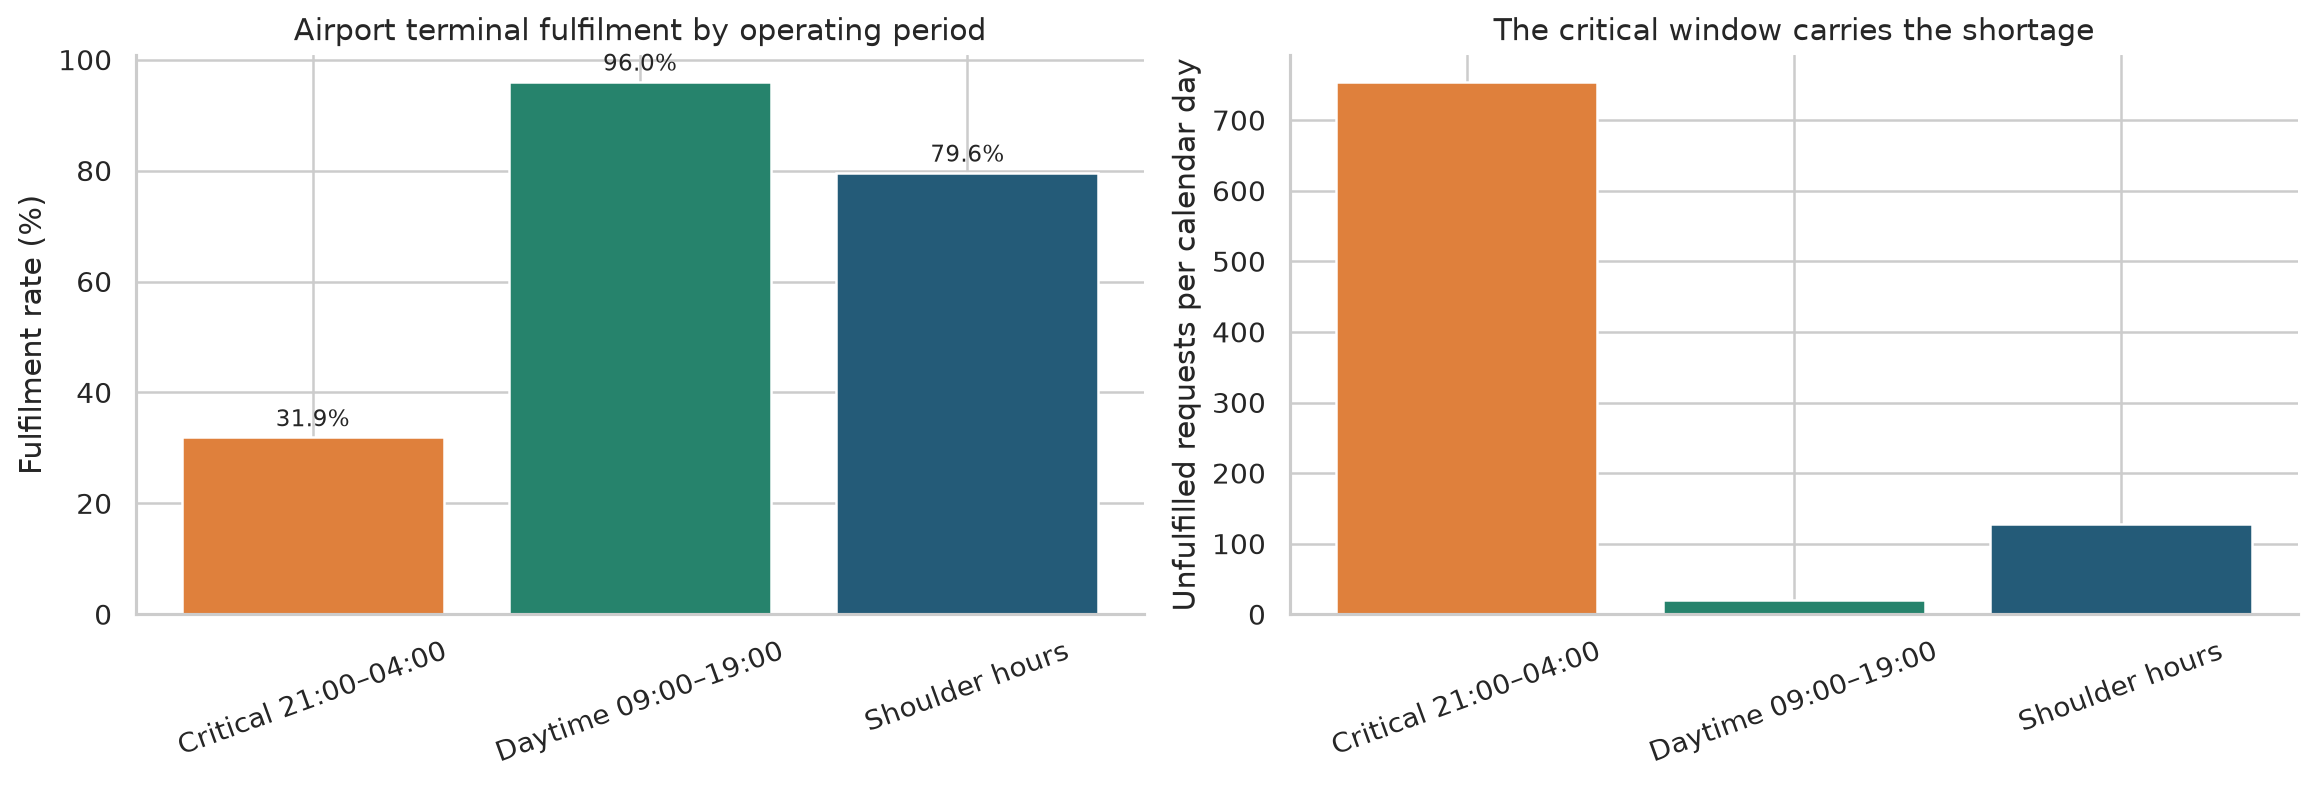

In [21]:
# I compare fulfilment and unfulfilled demand across the critical window, daytime, and shoulder hours in one figure.

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 4.5),
)

fulfilment_chart = axes[0]
unfulfilled_chart = axes[1]

# Chart 1: Fulfilment rate
fulfilment_chart.bar(
    period["period"],
    period_fulfilment_percentage,
    color=[ORANGE, GREEN, BLUE],
)

fulfilment_chart.set_ylabel("Fulfilment rate (%)")

fulfilment_chart.set_title(
    "Airport terminal fulfilment by operating period"
)

fulfilment_chart.tick_params(
    axis="x",
    rotation=20,
)

for position, value in enumerate(period_fulfilment_percentage):
    fulfilment_chart.text(
        position,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=9,
    )

# Chart 2: Unfulfilled requests
unfulfilled_chart.bar(
    period["period"],
    period_unfulfilled_daily,
    color=[ORANGE, GREEN, BLUE],
)

unfulfilled_chart.set_ylabel(
    "Unfulfilled requests per calendar day"
)

unfulfilled_chart.set_title(
    "The critical window carries the shortage"
)

unfulfilled_chart.tick_params(
    axis="x",
    rotation=20,
)

fig.tight_layout()

save_figure("airport_period_mismatch", fig)

In [22]:
# I prepare the hourly profile so the timing of the shortage can be seen rather than hidden inside a period average.

profile = market_tables["hour_profile"].copy()

hourly_fulfilment_percentage = profile["fulfilment_rate"] * 100

unfulfilled_per_terminal_hour = (
    profile["unfulfilled"] / profile["zone_hours"]
)

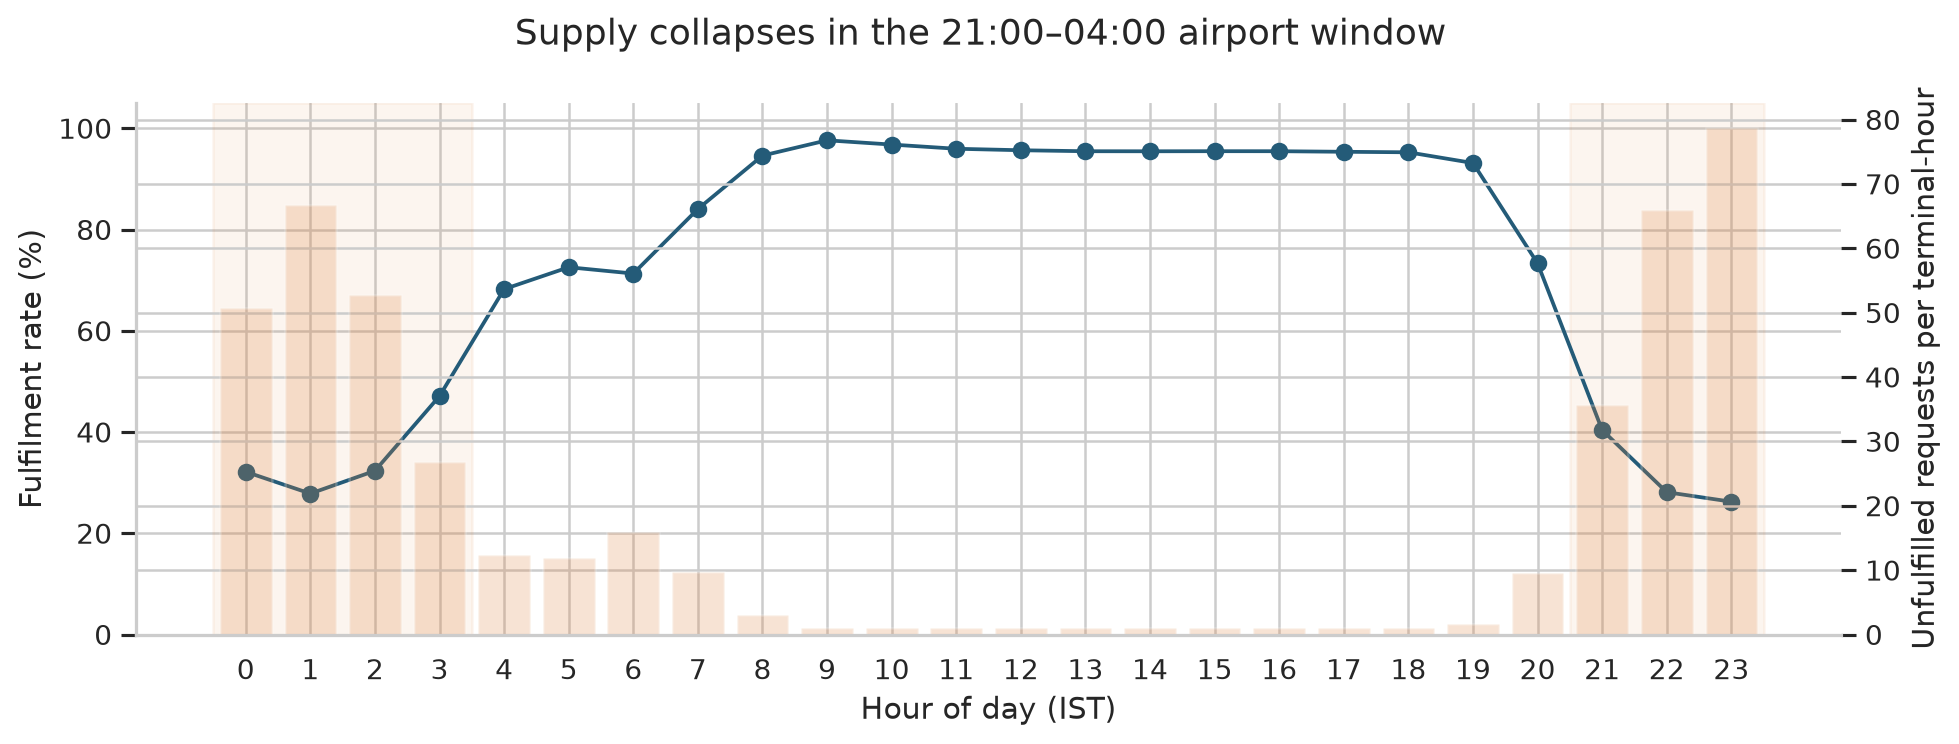

In [23]:
# I plot hourly fulfilment against unfulfilled requests per terminal-hour and shade the 21:00–04:00 window.

fig, ax1 = plt.subplots(figsize=(11, 4.2))

# Left axis: Fulfilment rate
ax1.plot(
    profile["hour"],
    hourly_fulfilment_percentage,
    marker="o",
    color=BLUE,
    label="Fulfilment rate",
)

ax1.set_xlabel("Hour of day (IST)")
ax1.set_ylabel("Fulfilment rate (%)")

ax1.set_xticks(range(24))
ax1.set_ylim(0, 105)

# Right axis: Unfulfilled requests per terminal-hour
ax2 = ax1.twinx()

ax2.bar(
    profile["hour"],
    unfulfilled_per_terminal_hour,
    alpha=0.22,
    color=ORANGE,
    label="Unfulfilled per terminal-hour",
)

ax2.set_ylabel("Unfulfilled requests per terminal-hour")

# Highlight the critical hours
ax1.axvspan(
    20.5,
    23.5,
    color=ORANGE,
    alpha=0.08,
)

ax1.axvspan(
    -0.5,
    3.5,
    color=ORANGE,
    alpha=0.08,
)

fig.suptitle(
    "Supply collapses in the 21:00–04:00 airport window"
)

fig.tight_layout()

save_figure("airport_hourly_profile", fig)

In [24]:
# I select the critical period for each month so May can identify the pattern and June can provide a simple validation check.

monthly = market_tables["monthly_period_summary"]

is_critical_period = monthly["period"].eq(PERIODS[0])

critical_monthly = monthly.loc[is_critical_period]

critical_monthly_percentage = (
    critical_monthly["fulfilment_rate"] * 100
)

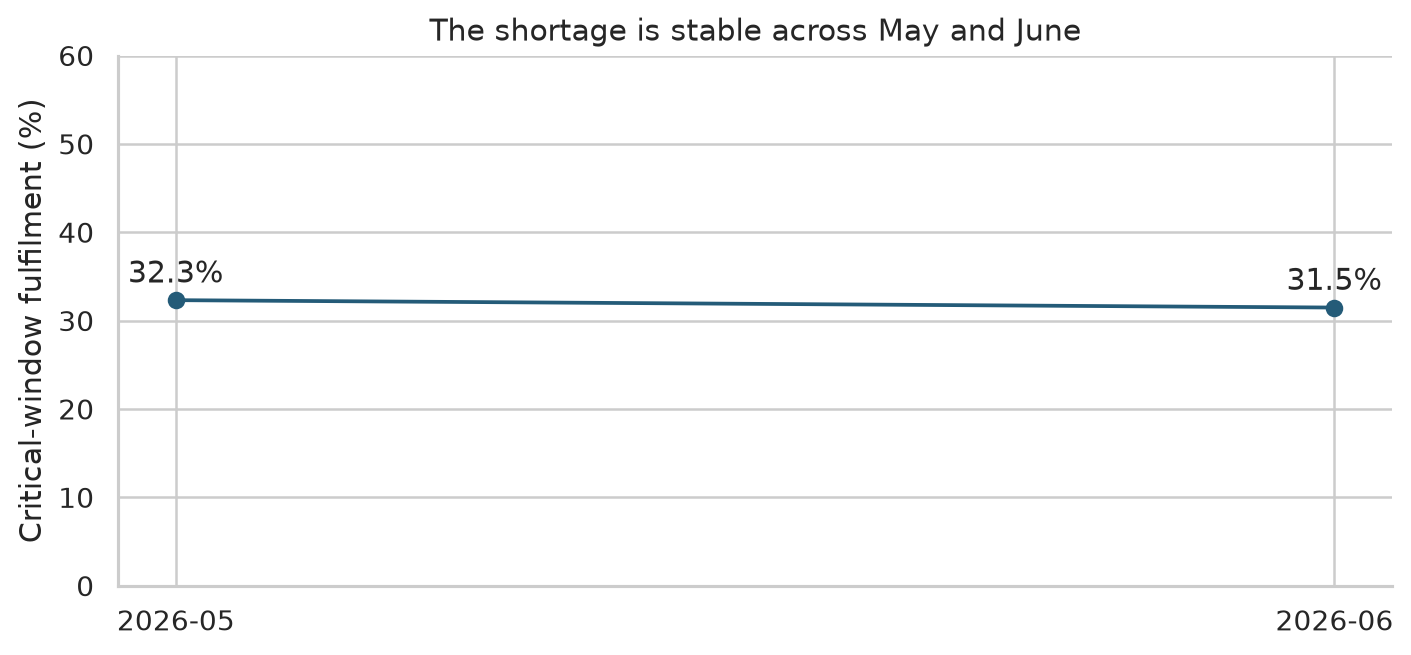

In [25]:
# I plot May and June critical-window fulfilment to see whether the overnight shortage is persistent across both months.

fig, ax = plt.subplots(figsize=(8, 3.8))

ax.plot(
    critical_monthly["month"],
    critical_monthly_percentage,
    marker="o",
    color=BLUE,
)

ax.set_ylim(0, 60)

ax.set_ylabel("Critical-window fulfilment (%)")

ax.set_title("The shortage is stable across May and June")

for position, value in enumerate(critical_monthly_percentage):
    ax.text(
        position,
        value + 2,
        f"{value:.1f}%",
        ha="center",
    )

fig.tight_layout()

save_figure("airport_month_validation", fig)

In [26]:
# I pull the daytime comparison values for unfulfilled demand, ETA, and surge so the overnight gap has a clear baseline.

is_daytime_period = period["period"].eq(PERIODS[1])

daytime_unfulfilled_per_day = period.loc[
    is_daytime_period,
    "unfulfilled_per_calendar_day",
].iloc[0]

daytime_eta = period.loc[
    is_daytime_period,
    "request_weighted_eta_min",
].iloc[0]

daytime_surge = period.loc[
    is_daytime_period,
    "request_weighted_surge",
].iloc[0]

In [27]:
# I write the B1 readout in plain language, combining fulfilment, demand loss, online supply, ETA, surge, and month validation.

b1_readout = (
    "**B1 readout:** in the 21:00–04:00 window, only "
    f"**{market['critical_fulfilment']:.1%}** of "
    f"{market['critical_requests']:,} requests were fulfilled, "
    f"leaving **{market['critical_unfulfilled']:,}** "
    f"unfulfilled (**{market['critical_unfulfilled_per_day']:.0f}/day**, "
    f"**{market['critical_unfulfilled_share']:.1%}** "
    "of the terminal's total unfulfilled requests). "
    f"Daytime fulfilment is **{market['daytime_fulfilment']:.1%}** "
    f"with **{daytime_unfulfilled_per_day:.0f}/day** unfulfilled. "
    "Online supply averages "
    f"**{market['critical_mean_online_per_terminal_hour']:.1f}** "
    "captains per terminal-hour "
    "in the critical window versus "
    f"**{market['daytime_mean_online_per_terminal_hour']:.1f}** daytime; "
    f"request-weighted ETA is **{market['critical_eta']:.1f}** "
    f"vs **{daytime_eta:.1f}** minutes "
    f"and surge is **{market['critical_surge']:.2f}×** "
    f"vs **{daytime_surge:.2f}×**. "
    "May and June critical fulfilment are "
    f"**{market['may_critical_fulfilment']:.1%}** and "
    f"**{market['june_critical_fulfilment']:.1%}**, respectively."
)

display(Markdown(b1_readout))

**B1 readout:** in the 21:00–04:00 window, only **31.9%** of 67,590 requests were fulfilled, leaving **46,020** unfulfilled (**754/day**, **83.6%** of the terminal's total unfulfilled requests). Daytime fulfilment is **96.0%** with **20/day** unfulfilled. Online supply averages **13.0** captains per terminal-hour in the critical window versus **46.9** daytime; request-weighted ETA is **9.6** vs **3.7** minutes and surge is **2.08×** vs **1.04×**. May and June critical fulfilment are **32.3%** and **31.5%**, respectively.

## B2 — Understand the post-trip return-loop problem

This section uses the trip sample separately from the marketplace counts to compare cancellation and return-fare outcomes by destination type.


In [28]:
# I analyse the sampled airport trips with a 24-hour end buffer and calendar-day bootstrap because exact completion times are not available.

trip_tables, trip_summary = analyse_airport_trips(
    airport,
    buffer_hours=24,
    bootstraps=BOOTSTRAPS,
    seed=SEED,
)

In [29]:
# I display the trip outcome tables and save a one-row summary for the report and dashboard.

for name, frame in trip_tables.items():
    show_table(name, frame)

trip_summary_table = pd.DataFrame([trip_summary])

show_table("trip_summary", trip_summary_table)

,drop_zone_type,sample_rows,cancelled,cancel_rate,mean_distance_km,reported_mean_fare_inr,return_eligible_records,next_fare,next_fare_rate,no_next_fare_rate,cancel_ci95_low,cancel_ci95_high,next_fare_ci95_low,next_fare_ci95_high
0,city_core,25282,2181,0.086,13.237,216.623,22711,11996,0.528,0.472,0.083,0.090,0.520,0.536
1,suburban,24643,5176,0.210,23.377,353.565,19130,3196,0.167,0.833,0.205,0.215,0.162,0.172
2,tech_park,10075,903,0.090,16.105,255.228,9025,3730,0.413,0.587,0.084,0.096,0.403,0.424


,outcome,suburban_minus_city_core,ci95_low,ci95_high
0,cancel,0.124,0.118,0.130
1,next_fare,-0.361,-0.371,-0.351


,drop_zone_type,size,mean,buffer_hours
0,city_core,23101,0.529,0
1,suburban,19467,0.167,0
2,tech_park,9172,0.413,0
3,city_core,22997,0.529,6
4,suburban,19391,0.167,6
5,tech_park,9139,0.413,6
6,city_core,22711,0.528,24
7,suburban,19130,0.167,24
8,tech_park,9025,0.413,24
9,city_core,22341,0.528,48


,drop_zone_type,critical,sample_rows,cancel_rate,next_fare_n,next_fare_rate
0,city_core,False,17824,0.072,16266,0.552
1,city_core,True,7458,0.119,6445,0.468
2,suburban,False,17454,0.196,13777,0.190
3,suburban,True,7189,0.244,5353,0.107
4,tech_park,False,7215,0.077,6551,0.439
5,tech_park,True,2860,0.121,2474,0.346


,month,drop_zone_type,sample_rows,cancel_rate,next_fare_n,next_fare_rate
0,2026-05,city_core,12847,0.087,11724,0.529
1,2026-05,suburban,12530,0.211,9891,0.165
2,2026-05,tech_park,5104,0.091,4638,0.413
3,2026-06,city_core,12435,0.085,10987,0.527
4,2026-06,suburban,12113,0.209,9239,0.169
5,2026-06,tech_park,4971,0.088,4387,0.414


,supported_strata,supported_rows,eligible_sample_rows,fraction_supported,city_core_standardized_cancel,suburban_standardized_cancel,gap_pp
0,312,33775,49925,0.677,0.094,0.197,10.372


,drop_zone_type,records,reported_fare,loaded_km,assumed_unpaid_km,total_scenario_km,unpaid_distance_fraction_if_no_next_fare,gross_fare_per_scenario_km
0,city_core,22711,"4,899,236.000","299,092.390",0.000,"299,092.390",0.000,16.380
1,suburban,19130,"6,720,469.000","443,921.380",0.000,"443,921.380",0.000,15.139
2,tech_park,9025,"2,294,637.000","144,648.980",0.000,"144,648.980",0.000,15.863
3,city_core,22711,"4,899,236.000","299,092.390","70,669.810","369,762.200",0.500,13.250
4,suburban,19130,"6,720,469.000","443,921.380","184,482.460","628,403.840",0.500,10.695
5,tech_park,9025,"2,294,637.000","144,648.980","42,558.265","187,207.245",0.500,12.257
6,city_core,22711,"4,899,236.000","299,092.390","141,339.620","440,432.010",1.000,11.124
7,suburban,19130,"6,720,469.000","443,921.380","368,964.920","812,886.300",1.000,8.267
8,tech_park,9025,"2,294,637.000","144,648.980","85,116.530","229,765.510",1.000,9.987


,sample_rows
hour,
0,2503
1,2451
2,2616
3,2393
4,2539
5,2517
6,2494
7,2569
8,2545


,sample_rows,return_eligible_records,return_buffer_hours,sample_cancel_rate,suburban_cancel_rate,core_cancel_rate,suburban_next_fare_rate,core_next_fare_rate,suburban_mean_distance_km,suburban_reported_fare,core_reported_fare,standardized_cancel_gap_pp,standardization_coverage,sample_exceeds_requests_cells,cancelled_with_return,suburban_gross_fare_per_scenario_km,city_core_gross_fare_per_scenario_km
0,60000,50866,24,0.138,0.210,0.086,0.167,0.528,23.377,353.565,216.623,10.372,0.677,380,2321,8.267,11.124


In [30]:
# I select cancellation and return-fare rates by destination type so the two operational outcomes can be plotted together.

outcomes = trip_tables["destination_sample_outcomes"].copy()

plot_outcomes = outcomes.set_index("drop_zone_type")

outcome_columns = [
    "cancel_rate",
    "next_fare_rate",
]

plot_outcomes = plot_outcomes[outcome_columns]

outcome_percentages = plot_outcomes.mul(100)

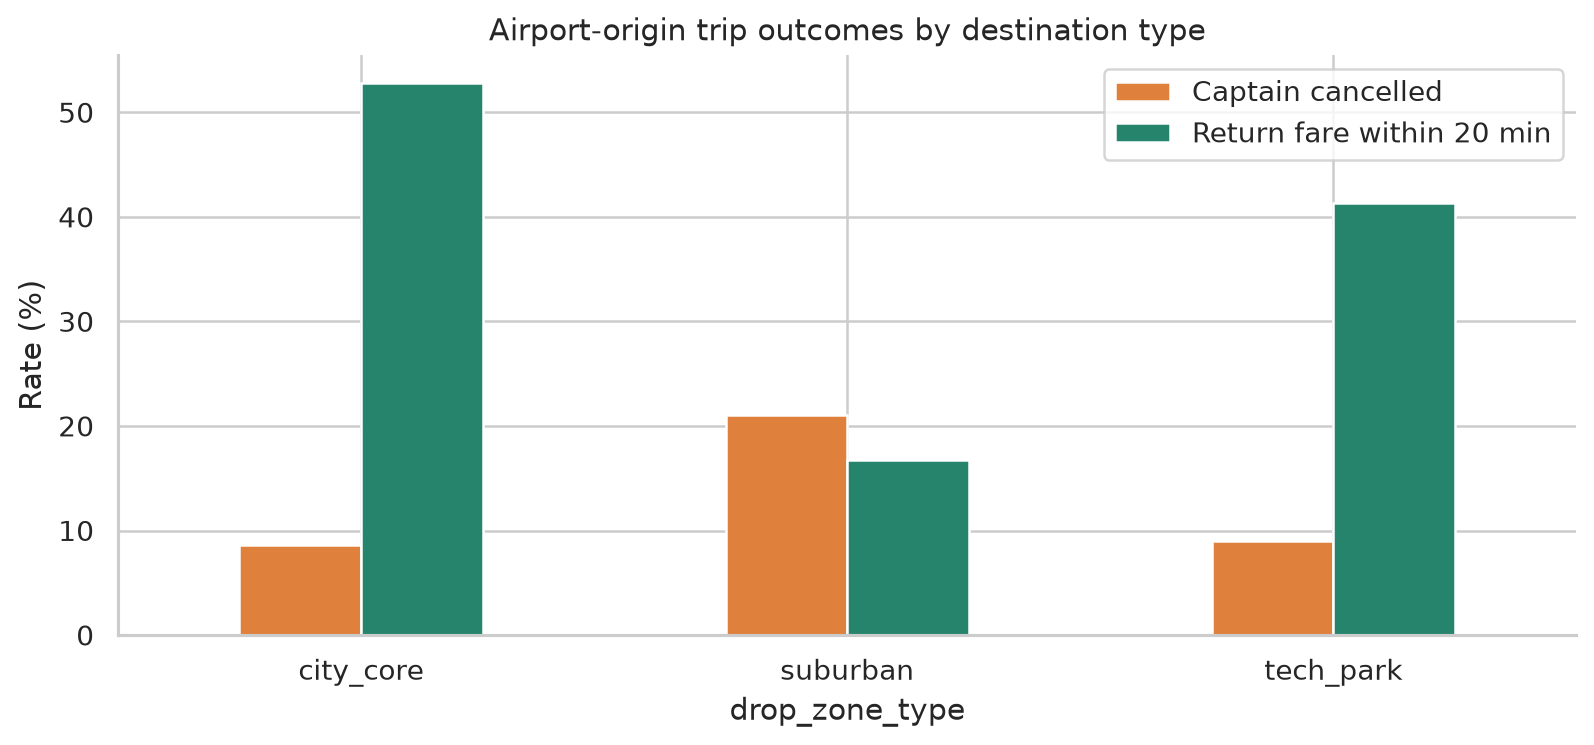

In [31]:
# I plot the destination comparison, keeping cancellation and return-fare availability as separate rates.

fig, ax = plt.subplots(figsize=(9, 4.3))

outcome_percentages.plot.bar(
    ax=ax,
    color=[ORANGE, GREEN],
)

ax.set_ylabel("Rate (%)")

ax.set_title(
    "Airport-origin trip outcomes by destination type"
)

ax.legend(
    ["Captain cancelled", "Return fare within 20 min"],
    loc="upper right",
)

ax.tick_params(
    axis="x",
    rotation=0,
)

fig.tight_layout()

save_figure("airport_trip_outcomes", fig)

In [32]:
# I calculate the raw suburban-minus-core gaps before showing the standardized comparison in the written readout.

raw_cancel_gap_pp = (
    trip_summary["suburban_cancel_rate"]
    - trip_summary["core_cancel_rate"]
) * 100

raw_next_fare_gap_pp = (
    trip_summary["suburban_next_fare_rate"]
    - trip_summary["core_next_fare_rate"]
) * 100

In [33]:
# I write the B2 readout with the sample size, cancellation gap, common-support coverage, return-fare gap, and the limits of the trip data.

b2_readout = (
    "**B2 readout:** the 24-hour-buffer sample has "
    f"**{trip_summary['sample_rows']:,}** rows and "
    f"**{trip_summary['return_eligible_records']:,}** "
    "return-fare-eligible rows. "
    "Suburban trips show "
    f"**{trip_summary['suburban_cancel_rate']:.1%}** cancellation "
    f"versus **{trip_summary['core_cancel_rate']:.1%}** "
    "for city-core trips: "
    f"a raw gap of **{raw_cancel_gap_pp:.1f} pp** "
    "and a time/distance-standardized gap of "
    f"**{trip_summary['standardized_cancel_gap_pp']:.1f} pp** over "
    f"**{trip_summary['standardization_coverage']:.1%}** "
    "of the shared strata. "
    f"Only **{trip_summary['suburban_next_fare_rate']:.1%}** "
    "of suburban trips receive a return fare within 20 minutes "
    f"versus **{trip_summary['core_next_fare_rate']:.1%}** "
    f"for city-core trips (gap **{raw_next_fare_gap_pp:.1f} pp**). "
    "Suburban trips average "
    f"**{trip_summary['suburban_mean_distance_km']:.1f} km** "
    "and reported fare "
    f"**INR {trip_summary['suburban_reported_fare']:.0f}**, "
    f"versus **{trip_summary['core_reported_fare']:.0f}** "
    "for the core. "
    "This supports a deadhead/return-loop problem, "
    "but not a causal claim about destination choice or earnings."
)

display(Markdown(b2_readout))

**B2 readout:** the 24-hour-buffer sample has **60,000** rows and **50,866** return-fare-eligible rows. Suburban trips show **21.0%** cancellation versus **8.6%** for city-core trips: a raw gap of **12.4 pp** and a time/distance-standardized gap of **10.4 pp** over **67.7%** of the shared strata. Only **16.7%** of suburban trips receive a return fare within 20 minutes versus **52.8%** for city-core trips (gap **-36.1 pp**). Suburban trips average **23.4 km** and reported fare **INR 354**, versus **217** for the core. This supports a deadhead/return-loop problem, but not a causal claim about destination choice or earnings.

## B3 — Size a timed supply pilot before acquisition

This section turns the observed shortage into transparent roster, recovery, and cost scenarios and sets the gate for any future airport acquisition test.


In [34]:
# I size an illustrative intervention using a 20-slot roster, 80% attendance, stated productivity, and bounded fallback cost assumptions.

pilot_tables, pilot = airport_intervention_scenarios(
    market,
    roster=20,
    attendance=0.8,
    hourly_incentive_inr=30.0,
    fallback_inr=60.0,
    fallback_nightly_cap=20,
)

In [35]:
# I display the pilot capacity and cost tables so the recommendation can be checked at several recovery levels.

for name, frame in pilot_tables.items():
    show_table(name, frame)

pilot_summary_table = pd.DataFrame([pilot])

show_table("pilot_summary", pilot_summary_table)

,recovered_fraction_of_unfulfilled,extra_fulfilled_per_night,extra_per_30_day_month,assumed_completions_per_effective_captain_hour,extra_effective_captain_hours,seven_hour_roster_slots_at_80pct_attendance
0,0.100,75.443,"2,263.279",0.500,150.885,26.944
1,0.100,75.443,"2,263.279",0.750,100.590,17.963
2,0.100,75.443,"2,263.279",1.000,75.443,13.472
3,0.250,188.607,"5,658.197",0.500,377.213,67.359
4,0.250,188.607,"5,658.197",0.750,251.475,44.906
5,0.250,188.607,"5,658.197",1.000,188.607,33.680
6,0.500,377.213,"11,316.393",0.500,754.426,134.719
7,0.500,377.213,"11,316.393",0.750,502.951,89.813
8,0.500,377.213,"11,316.393",1.000,377.213,67.359


,recovered_fraction,extra_per_night,illustrative_variable_cost_per_night,cost_per_extra_fulfilled_request_inr
0,0.000,0.000,"4,560.000",NaN
1,0.050,37.721,"4,560.000",120.887
2,0.100,75.443,"4,560.000",60.443
3,0.200,150.885,"4,560.000",30.222


,pilot_roster_slots,pilot_attendance_assumption,pilot_recovery_target,pilot_extra_fulfilled_per_night,pilot_extra_per_30_day_month,pilot_capacity_at_assumed_productivity,pilot_expected_nightly_variable_cost,pilot_max_nightly_variable_cost,pilot_cost_per_incremental_fulfilment_at_target,pilot_expected_30_day_cost,pilot_max_30_day_cost,pilot_14_treatment_night_expected_cost,pilot_14_treatment_night_cost_cap,pilot_hourly_incentive_inr,pilot_fallback_inr,pilot_fallback_nightly_cap,trial_nights,trial_planning_mde_pp,acquisition_decision
0,20,0.800,0.100,75.443,"2,263.279",84.000,"4,560.000","5,400.000",60.443,"136,800.000","162,000.000","63,840.000","75,600.000",30.000,60.000,20,28,3.728,Do not fund a blanket catchment signup-bonus p...


In [36]:
# I select the capacity scenarios and name the productivity column that will be used in the pilot chart.

capacity = pilot_tables["capacity_scenarios"].copy()

productivity_column = "assumed_completions_per_effective_captain_hour"

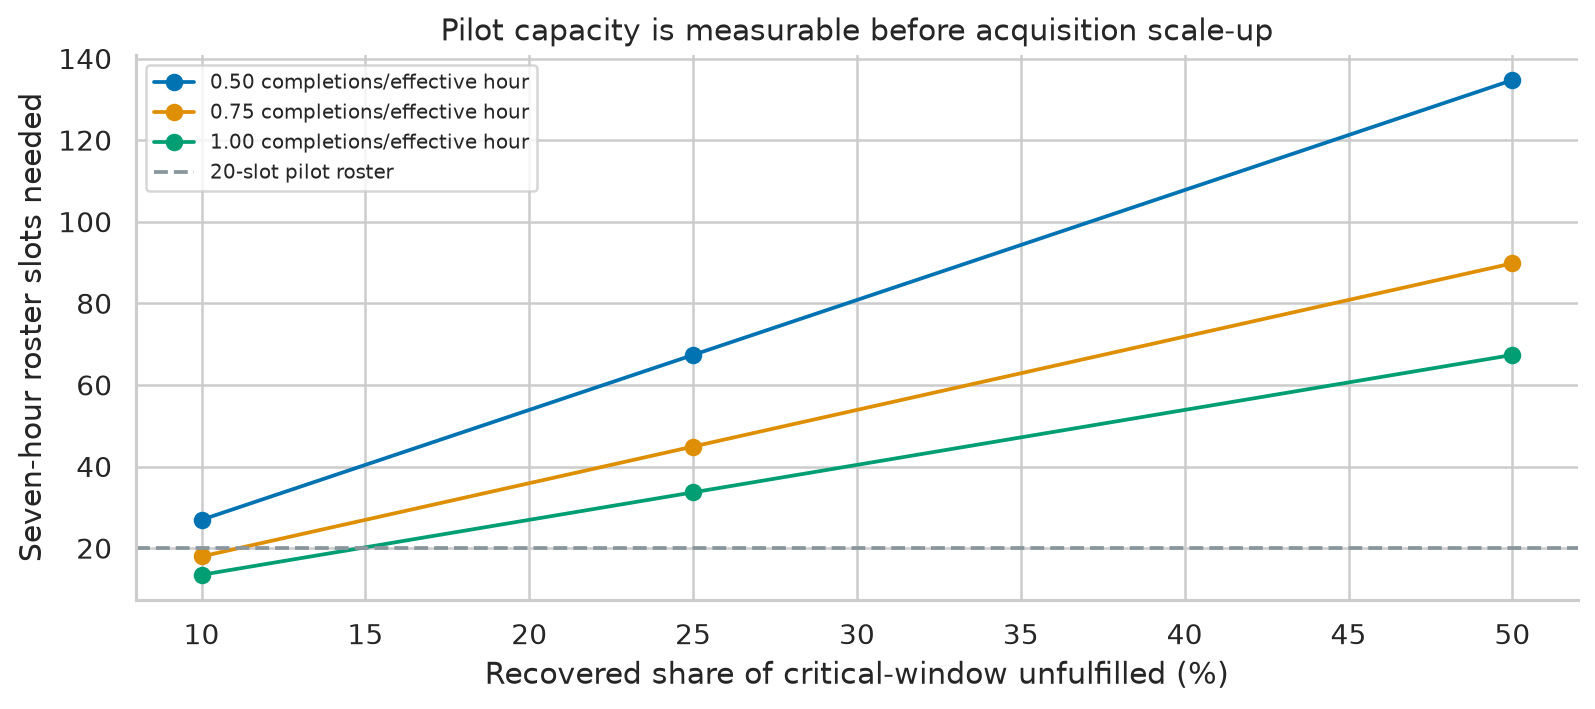

In [37]:
# I show how many roster slots would be needed at different productivity and recovery levels, with the proposed 20-slot roster as a reference.

fig, ax = plt.subplots(figsize=(9, 4.1))

for productivity, group in capacity.groupby(productivity_column):
    recovered_percentage = (
        group["recovered_fraction_of_unfulfilled"] * 100
    )

    roster_slots = group[
        "seven_hour_roster_slots_at_80pct_attendance"
    ]

    line_label = (
        f"{productivity:.2f} completions/effective hour"
    )

    ax.plot(
        recovered_percentage,
        roster_slots,
        marker="o",
        label=line_label,
    )

# Reference line for the proposed roster
ax.axhline(
    20,
    color=GREY,
    linestyle="--",
    label="20-slot pilot roster",
)

ax.set_xlabel(
    "Recovered share of critical-window unfulfilled (%)"
)

ax.set_ylabel("Seven-hour roster slots needed")

ax.set_title(
    "Pilot capacity is measurable before acquisition scale-up"
)

ax.legend(fontsize=8)

fig.tight_layout()

save_figure("airport_pilot_capacity", fig)

In [38]:
# I pull the pilot's extra fulfilment, capacity, nightly cost, and 30-day cost into clearly named values for the decision text.

extra_fulfilled_per_night = pilot["pilot_extra_fulfilled_per_night"]

extra_fulfilled_per_month = pilot["pilot_extra_per_30_day_month"]

pilot_nightly_capacity = pilot[
    "pilot_capacity_at_assumed_productivity"
]

expected_nightly_cost = pilot[
    "pilot_expected_nightly_variable_cost"
]

maximum_nightly_cost = pilot[
    "pilot_max_nightly_variable_cost"
]

cost_per_incremental_fulfilment = pilot[
    "pilot_cost_per_incremental_fulfilment_at_target"
]

expected_monthly_cost = pilot["pilot_expected_30_day_cost"]

In [39]:
# I write the B3 decision: test timed availability and the return loop first, then consider acquisition only if the pilot improves the measured outcomes.

b3_readout = (
    "**B3 decision:** a 10% recovery target equals "
    f"**{extra_fulfilled_per_night:.0f}** "
    "additional fulfilled requests per critical night, "
    f"or **{extra_fulfilled_per_month:.0f}** per 30-day month. "
    "The illustrative 20-slot roster has capacity for "
    f"**{pilot_nightly_capacity:.0f}** "
    "completions/night under the stated assumptions. "
    "Expected variable cost is "
    f"**INR {expected_nightly_cost:,.0f}/night** "
    f"(cap INR {maximum_nightly_cost:,.0f}), "
    f"or **INR {cost_per_incremental_fulfilment:.0f}** "
    "per incremental fulfilment at the 10% target. "
    f"A 30-day scenario costs INR {expected_monthly_cost:,.0f}; "
    "these values exclude acquisition bonus, fixed engineering, "
    "airport fees and captain earnings. "
    "Only if this timed pilot improves fulfilled demand and return "
    "economics should Supply size a catchment acquisition test."
)

display(Markdown(b3_readout))

**B3 decision:** a 10% recovery target equals **75** additional fulfilled requests per critical night, or **2263** per 30-day month. The illustrative 20-slot roster has capacity for **84** completions/night under the stated assumptions. Expected variable cost is **INR 4,560/night** (cap INR 5,400), or **INR 60** per incremental fulfilment at the 10% target. A 30-day scenario costs INR 136,800; these values exclude acquisition bonus, fixed engineering, airport fees and captain earnings. Only if this timed pilot improves fulfilled demand and return economics should Supply size a catchment acquisition test.

In [40]:
# I combine the marketplace, trip, and pilot outputs into one summary dictionary for export.

summary = {}

summary.update(market)
summary.update(trip_summary)
summary.update(pilot)

In [41]:
# I store the ordered critical-hour list as ordinary integers so it serializes cleanly in the summary file.

critical_hours = []

for hour in CRITICAL_HOURS:
    critical_hours.append(int(hour))

summary["critical_hours"] = critical_hours

In [42]:
# I record the airport input fingerprints and the Part B decision so stale outputs can be detected and the recommendation is explicit.

summary["raw_input_fingerprints"] = dict(
    airport_input_fingerprint(DATA_DIR)
)

summary["part_b_decision"] = (
    "No blanket catchment acquisition bonus yet; "
    "run a timed supply and return-loop pilot."
)

In [43]:
# I export every collected table as CSV so the dashboard and reviewers can inspect the calculations behind the charts.

for name, frame in tables.items():
    table_path = OUT / f"{name}.csv"

    frame.to_csv(
        table_path,
        index=True,
    )

In [44]:
# I convert NumPy numbers into normal Python numbers because JSON cannot serialize NumPy scalar types directly.

def convert_numpy_value(value):
    if isinstance(value, np.floating):
        return float(value)

    elif isinstance(value, np.integer):
        return int(value)

    else:
        return value

In [45]:
# I save the headline summary as readable JSON for the dashboard and for later reproducibility checks.

summary_json = json.dumps(
    summary,
    indent=2,
    default=convert_numpy_value,
)

summary_path = OUT / "summary.json"

summary_characters_written = summary_path.write_text(
    summary_json,
    encoding="utf-8",
)

In [46]:
# I build a run manifest with the date, Python version, seed, bootstrap count, package versions, and raw-input details.

manifest = {
    "created_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    "python": platform.python_version(),
    "seed": SEED,
    "bootstrap_replicates": BOOTSTRAPS,
    "cutoff_ist": str(CUTOFF),
}

package_names = [
    "pandas",
    "numpy",
    "scipy",
    "matplotlib",
]

package_versions = {}

for package_name in package_names:
    package_versions[package_name] = importlib.metadata.version(
        package_name
    )

manifest["packages"] = package_versions

manifest["raw_inputs"] = airport.manifest

In [47]:
# I save the manifest beside the summary so every Part B export records how it was produced.

manifest_json = json.dumps(
    manifest,
    indent=2,
    default=str,
)

manifest_path = OUT / "run_manifest.json"

manifest_characters_written = manifest_path.write_text(
    manifest_json,
    encoding="utf-8",
)

In [48]:
# I build the one general submission memo and six-slide deck, then show the final report links.

from scripts.build_combined_reports import create_combined_reports
reports = create_combined_reports(ROOT)
for path in reports:
    display(Markdown(f'[{path.name}]({path.relative_to(ROOT).as_posix()})'))

[memo.pdf](deliverables/memo.pdf)

[presentation.pdf](deliverables/presentation.pdf)